# JaxESN validation — weights, states, and speed

Three checks before trusting the benchmark numbers:

| # | What | Expected |
|---|------|----------|
| 1 | **Weight identity** | `JaxESN.W` ≈ `Reservoir.W` (same seed → same matrices, modulo float32 cast) |
| 2 | **State identity** | Trajectories match within float32 tolerance (~1e-6 max diff) |
| 3 | **Speed** | JaxESN faster than reservoirpy beyond a short warm-up crossover |

Both models use identical hyper-parameters (`units=100, lr=1.0, sr=0.9`).

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path(".").resolve()))   # benchmarks/
sys.path.insert(0, str(pathlib.Path("..").resolve()))  # project root

import time
import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import reservoirpy as rpy
from reservoirpy.nodes import Reservoir

from esn import JaxESN

try:
    rpy.verbosity(0)
except AttributeError:
    pass

print(f"reservoirpy : {rpy.__version__}")
print(f"JAX backend : {jax.default_backend()}")

# ── shared hyper-parameters ───────────────────────────────────────────────
UNITS = 100
LR    = 1.0
SR    = 0.9
SEED  = 42
D_IN  = 3    # input dimension (matches Lorenz benchmark)

reservoirpy : 0.4.1
JAX backend : cpu


## 1 — Weight identity

`JaxESN` calls `reservoirpy.nodes.Reservoir.initialize()` with the same seed
and then copies the resulting matrices.  After a float32 cast the matrices
should match to within single-precision rounding (~1 × 10⁻⁷).

In [2]:
# ── reference reservoirpy reservoir ──────────────────────────────────────
rpy_res = Reservoir(UNITS, lr=LR, sr=SR, seed=SEED)
dummy   = np.zeros((1, D_IN), dtype=np.float64)
rpy_res.initialize(dummy)

# ── JaxESN (triggers the same reservoirpy init internally) ────────────────
jax_esn = JaxESN(UNITS, lr=LR, sr=SR, seed=SEED)
jax_esn._init_weights(D_IN)

# ── extract dense weight matrices ─────────────────────────────────────────
W_rpy  = rpy_res.W.toarray() if hasattr(rpy_res.W, "toarray") else np.asarray(rpy_res.W)
Win_rpy = rpy_res.Win.toarray() if hasattr(rpy_res.Win, "toarray") else np.asarray(rpy_res.Win)

W_jax  = np.asarray(jax_esn._W,   dtype=np.float64)
Win_jax = np.asarray(jax_esn._Win, dtype=np.float64)

dW   = np.abs(W_rpy   - W_jax)
dWin = np.abs(Win_rpy - Win_jax)

print("W   — shape:", W_rpy.shape)
print(f"    max |W_rpy - W_jax|   = {dW.max():.2e}  (expected ≲ 1e-7 from float32 cast)")
print(f"    mean |W_rpy - W_jax|  = {dW.mean():.2e}")
print()
print("Win — shape:", Win_rpy.shape)
print(f"    max |Win_rpy - Win_jax| = {dWin.max():.2e}")
print(f"    mean |Win_rpy - Win_jax| = {dWin.mean():.2e}")

assert dW.max()   < 1e-6, "W matrices differ by more than expected"
assert dWin.max() < 1e-6, "Win matrices differ by more than expected"
print("\n✓  Weights match within float32 precision.")

W   — shape: (100, 100)
    max |W_rpy - W_jax|   = 2.84e-08  (expected ≲ 1e-7 from float32 cast)
    mean |W_rpy - W_jax|  = 4.92e-10

Win — shape: (100, 3)
    max |Win_rpy - Win_jax| = 0.00e+00
    mean |Win_rpy - Win_jax| = 0.00e+00

✓  Weights match within float32 precision.


## 2 — State identity

Run both models on the same random input sequence and compare
the state trajectories step by step.

* reservoirpy runs in **float64**.
* JaxESN runs in **float32** (as used in the benchmark).

Differences come from the float32 cast of weights and accumulation,
so max absolute error should be O(1 × 10⁻⁵) or smaller.

State shape         : (500, 100)
Max  |s_rpy - s_jax| : 2.650e-07
Mean |s_rpy - s_jax| : 3.446e-08
Std  |s_rpy - s_jax| : 2.788e-08

✓  States agree within expected float32 tolerance.


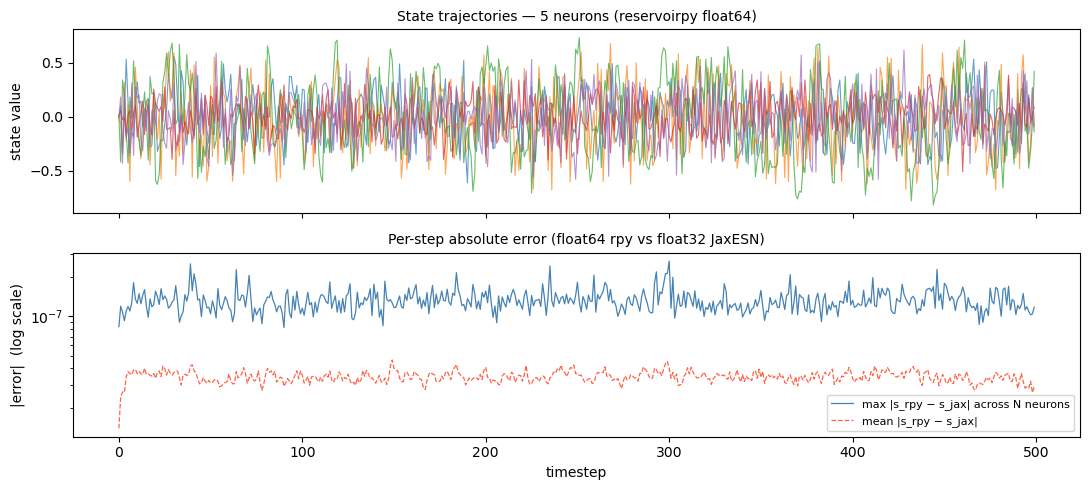

In [3]:
rng = np.random.default_rng(0)
T   = 500
X   = rng.uniform(-1, 1, size=(T, D_IN)).astype(np.float32)

# ── reservoirpy run ───────────────────────────────────────────────────────
rpy_res2 = Reservoir(UNITS, lr=LR, sr=SR, seed=SEED)  # fresh instance
states_rpy = rpy_res2.run(X.astype(np.float64))        # (T, N) float64

# ── JaxESN run ────────────────────────────────────────────────────────────
jax_esn2  = JaxESN(UNITS, lr=LR, sr=SR, seed=SEED)    # fresh instance
states_jax = jax_esn2.run(X)                           # (T, N) float32 → numpy

diff = np.abs(states_rpy - states_jax.astype(np.float64))
print(f"State shape         : {states_jax.shape}")
print(f"Max  |s_rpy - s_jax| : {diff.max():.3e}")
print(f"Mean |s_rpy - s_jax| : {diff.mean():.3e}")
print(f"Std  |s_rpy - s_jax| : {diff.std():.3e}")

assert diff.max() < 1e-4, f"States diverged: max diff = {diff.max():.3e}"
print("\n✓  States agree within expected float32 tolerance.")

# ── plot: error over time for 5 neurons ──────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(11, 5), sharex=True)

axes[0].plot(states_rpy[:, :5], lw=0.8, alpha=0.7)
axes[0].set_title("State trajectories — 5 neurons (reservoirpy float64)", fontsize=10)
axes[0].set_ylabel("state value")

axes[1].semilogy(diff.max(axis=1), color="steelblue", lw=0.9,
                 label="max |s_rpy − s_jax| across N neurons")
axes[1].semilogy(diff.mean(axis=1), color="tomato", lw=0.9, ls="--",
                 label="mean |s_rpy − s_jax|")
axes[1].set_xlabel("timestep")
axes[1].set_ylabel("|error|  (log scale)")
axes[1].set_title("Per-step absolute error (float64 rpy vs float32 JaxESN)", fontsize=10)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## 3 — Speed comparison

Both models are run on input sequences of increasing length.

* **JaxESN** is JIT-compiled once (warm-up cell below), then timed.
* **reservoirpy** uses its default Python `for`-loop (`_run`).

Each measurement is repeated `N_REPEAT` times and the **median** is reported
to reduce OS-scheduler noise.

In [4]:
# ── JIT warm-up — compile once for each sequence length we'll benchmark ──
# (reservoirpy has no compilation step — no warm-up needed)

LENGTHS = [50, 100, 250, 500, 1000, 2000, 4000, 8000]

warmup_esn = JaxESN(UNITS, lr=LR, sr=SR, seed=SEED)
for T_w in LENGTHS:
    X_w = np.zeros((T_w, D_IN), dtype=np.float32)
    warmup_esn.run(X_w)          # triggers JIT for this (T_w, D_IN) shape
    warmup_esn.reset_state()

print(f"JIT warm-up done for lengths: {LENGTHS}")

JIT warm-up done for lengths: [50, 100, 250, 500, 1000, 2000, 4000, 8000]


In [5]:
N_REPEAT = 20   # median over this many runs per length
rng = np.random.default_rng(1)

times_rpy = []
times_jax = []

for T_bench in LENGTHS:
    X_bench = rng.uniform(-1, 1, size=(T_bench, D_IN)).astype(np.float32)

    # ── reservoirpy ──────────────────────────────────────────────────────
    res_bench = Reservoir(UNITS, lr=LR, sr=SR, seed=SEED)
    res_bench.initialize(np.zeros((1, D_IN)))
    t_rpy = []
    for _ in range(N_REPEAT):
        res_bench.state = {"out": np.zeros(UNITS)}   # reset state
        t0 = time.perf_counter()
        res_bench.run(X_bench.astype(np.float64))
        t_rpy.append(time.perf_counter() - t0)

    # ── JaxESN (already compiled) ─────────────────────────────────────────
    esn_bench = JaxESN(UNITS, lr=LR, sr=SR, seed=SEED)
    esn_bench._init_weights(D_IN)
    t_jax = []
    for _ in range(N_REPEAT):
        esn_bench.reset_state()
        t0 = time.perf_counter()
        esn_bench.run(X_bench)   # np.asarray() inside blocks until done
        t_jax.append(time.perf_counter() - t0)

    times_rpy.append(np.median(t_rpy) * 1e3)
    times_jax.append(np.median(t_jax) * 1e3)
    speedup = times_rpy[-1] / times_jax[-1]
    print(f"T={T_bench:>5}  rpy={times_rpy[-1]:6.2f} ms  "
          f"jax={times_jax[-1]:6.2f} ms  "
          f"speedup={speedup:.1f}×")

T=   50  rpy=  0.40 ms  jax=  0.12 ms  speedup=3.4×
T=  100  rpy=  0.77 ms  jax=  0.17 ms  speedup=4.5×
T=  250  rpy=  1.97 ms  jax=  0.33 ms  speedup=6.0×
T=  500  rpy=  4.06 ms  jax=  0.61 ms  speedup=6.6×
T= 1000  rpy=  7.86 ms  jax=  1.10 ms  speedup=7.2×
T= 2000  rpy= 15.50 ms  jax=  2.05 ms  speedup=7.6×
T= 4000  rpy= 31.56 ms  jax=  4.06 ms  speedup=7.8×
T= 8000  rpy= 62.68 ms  jax=  8.06 ms  speedup=7.8×


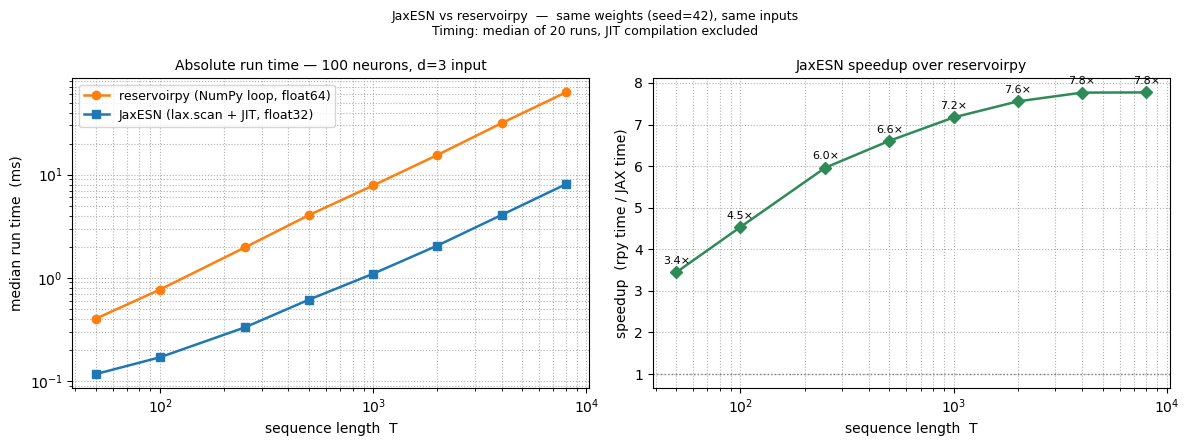

In [6]:
speedups = [r / j for r, j in zip(times_rpy, times_jax)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

# ── Absolute run time ──────────────────────────────────────────────────────
ax1.plot(LENGTHS, times_rpy, "o-", color="tab:orange", lw=1.8, label="reservoirpy (NumPy loop, float64)")
ax1.plot(LENGTHS, times_jax, "s-", color="tab:blue",   lw=1.8, label="JaxESN (lax.scan + JIT, float32)")
ax1.set_xlabel("sequence length  T")
ax1.set_ylabel("median run time  (ms)")
ax1.set_title("Absolute run time — 100 neurons, d=3 input", fontsize=10)
ax1.legend(fontsize=9)
ax1.set_yscale("log")
ax1.set_xscale("log")
ax1.grid(True, which="both", ls=":")

# ── Speedup ratio ─────────────────────────────────────────────────────────
ax2.axhline(1.0, color="gray", ls=":", lw=1)
ax2.plot(LENGTHS, speedups, "D-", color="seagreen", lw=1.8)
for T_val, sp in zip(LENGTHS, speedups):
    ax2.text(T_val, sp + 0.15, f"{sp:.1f}×", ha="center", va="bottom", fontsize=8)
ax2.set_xlabel("sequence length  T")
ax2.set_ylabel("speedup  (rpy time / JAX time)")
ax2.set_title("JaxESN speedup over reservoirpy", fontsize=10)
ax2.set_xscale("log")
ax2.grid(True, which="both", ls=":")

plt.suptitle(
    "JaxESN vs reservoirpy  —  same weights (seed=42), same inputs\n"
    "Timing: median of 20 runs, JIT compilation excluded",
    fontsize=9)
plt.tight_layout()
plt.show()